# Modelo SARIMAX: Aplicación de variables exógenas y estacionalidad

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from mlforecast import MLForecast

# Modelo ARIMA con stasforecast
from statsforecast import StatsForecast
from statsforecast.models import ARIMA

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 4)

## Problema a resolver

Utilizar el set de datos de demanda de electricidad que tiene un registro histórico de demnda en MW/h de una ciudad en el últio año. También se tienen los datos de temperatura horaria en el mismo periodo de tiempo. Esa va a ser la variable exógena a utilizar.

> Construir un modelo SARIMAX para pronosticar el nivel de demanda con un horizonte de 7 días en el futuro.

### Datos

In [31]:
df = pd.read_csv('datos/demanda_electricidad_sarimax.csv',
                parse_dates=['ds'])
df

,unique_id,ds,temperatura,y
0,demanda_electricidad,2025-01-01,15.7,131.2
1,demanda_electricidad,2025-01-02,15.0,135.1
2,demanda_electricidad,2025-01-03,16.3,129.1
3,demanda_electricidad,2025-01-04,17.8,117.4
4,demanda_electricidad,2025-01-05,15.3,120.7
...,...,...,...,...
360,demanda_electricidad,2025-12-27,14.9,124.9
361,demanda_electricidad,2025-12-28,16.6,119.8
362,demanda_electricidad,2025-12-29,14.3,136.9
363,demanda_electricidad,2025-12-30,15.3,136.0


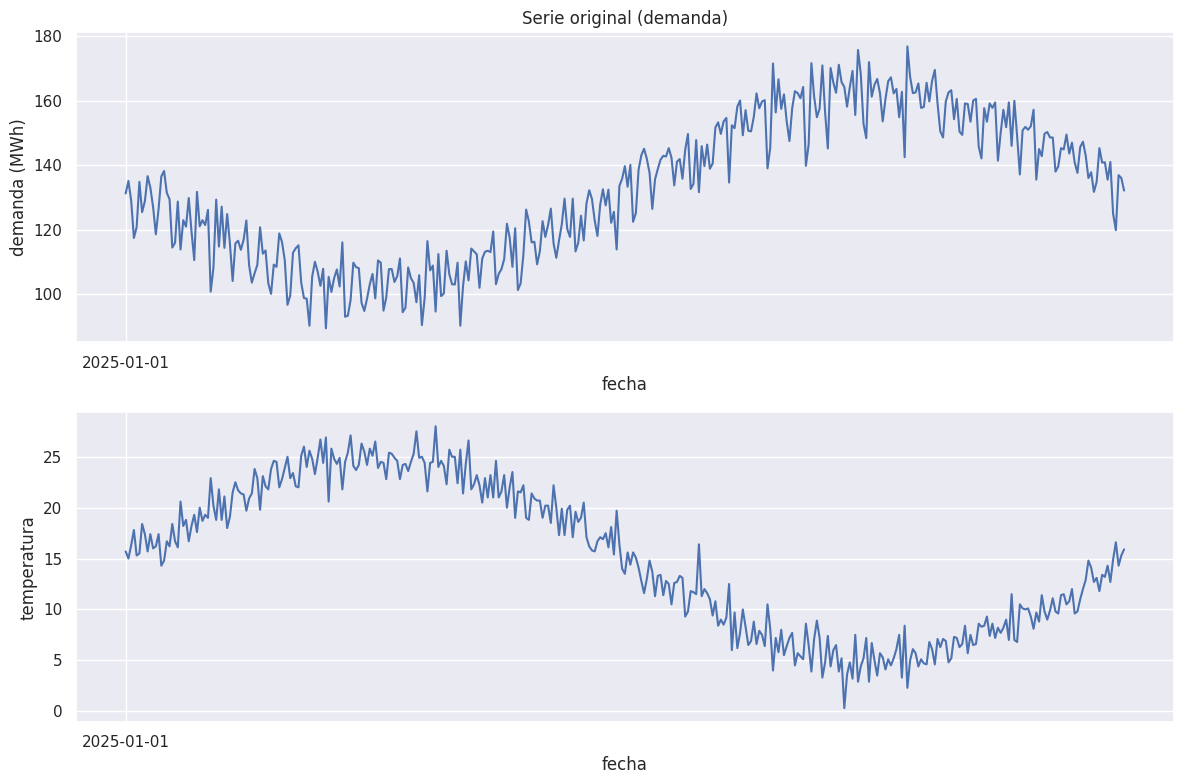

In [32]:
# Graficar serie y variables exógenas
fig, axs = plt.subplots(2,1,figsize=(12,8))

# Serie
sns.lineplot(df, x="ds", y="y", ax=axs[0])
axs[0].set_title('Serie original (demanda)')
axs[0].set_xlabel('fecha')
axs[0].set_ylabel('demanda (MWh)')
ticks = axs[0].get_xticks()
n = 60
axs[0].set_xticks(ticks[::n])

# Variable exógena (temperatura)
sns.lineplot(df, x="ds", y="temperatura", ax=axs[1])
axs[1].set_xlabel('fecha')
axs[1].set_xticks(ticks[::n])

plt.tight_layout();

## Estimación de los parámetros del modelo SARIMAX

1. Crear el set de entrenamiento y prueba
2. Ajustar un modelo de regresión **sobre las variables exógenas**
3. Calcular los residuales del modelo obtenido en (2)
4. Definir los parámetros del modelo SARIMA que se construirá **sobre los residuales obtenidos en (3)**
5. Habiendo definido los parámetros del modelo SARIMA (4), entrenar y validar el modelo SARIMAX
6. Generar pronósticos con el modelo obtenido en (5)

### 1. Set de entrenamiento y pruebas

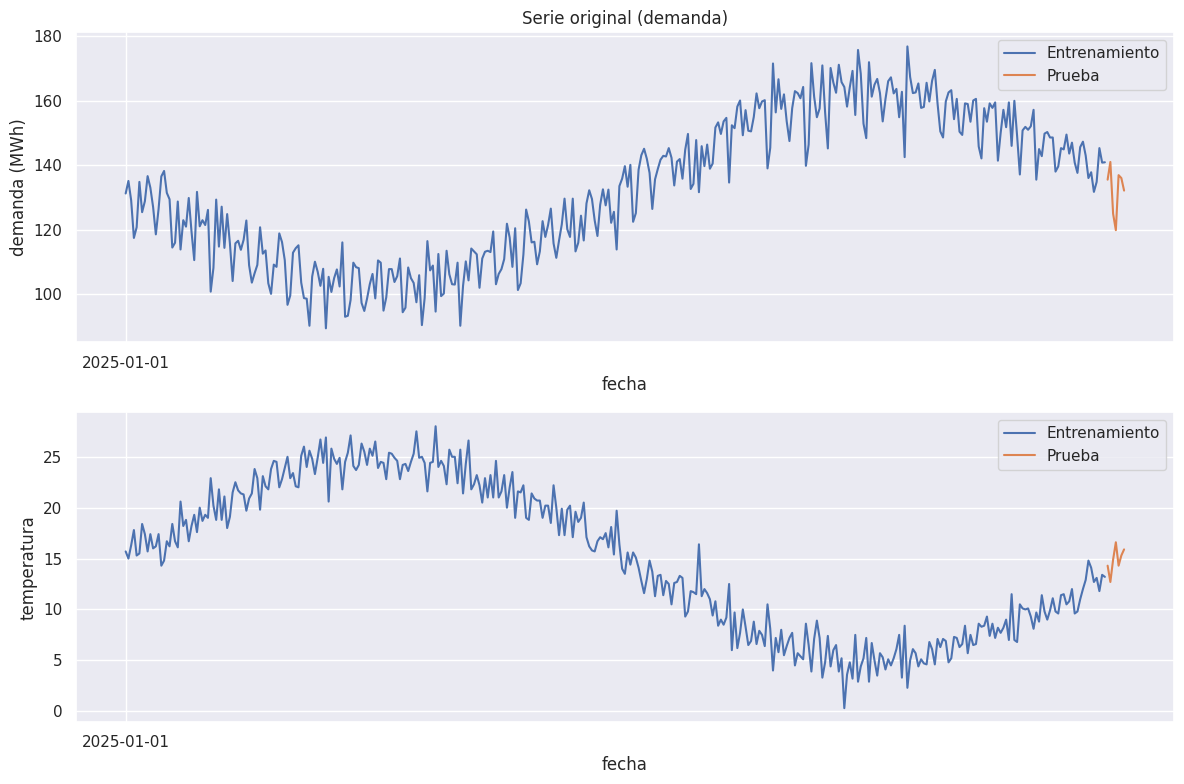

In [33]:
# Entrenamiento y prueba
df_train = df[:-7]
df_test = df[-7:] # Últimos 7 días de prueba

# Graficar
fig, axs = plt.subplots(2,1,figsize=(12,8))

# Serie
sns.lineplot(df_train, x="ds", y="y", ax=axs[0], label='Entrenamiento')
sns.lineplot(df_test, x="ds", y="y", ax=axs[0], label='Prueba')
axs[0].set_title('Serie original (demanda)')
axs[0].set_xlabel('fecha')
axs[0].set_ylabel('demanda (MWh)')
ticks = axs[0].get_xticks()
n = 60
axs[0].set_xticks(ticks[::n])

# Variables exógenas
sns.lineplot(df_train, x="ds", y="temperatura", ax=axs[1], label='Entrenamiento')
sns.lineplot(df_test, x="ds", y="temperatura", ax=axs[1], label='Prueba')
axs[1].set_xticks(ticks[::n])
axs[1].set_xlabel('fecha')
axs[1].legend()

plt.tight_layout();

### 2. Modelo de regresión para variables exógenas

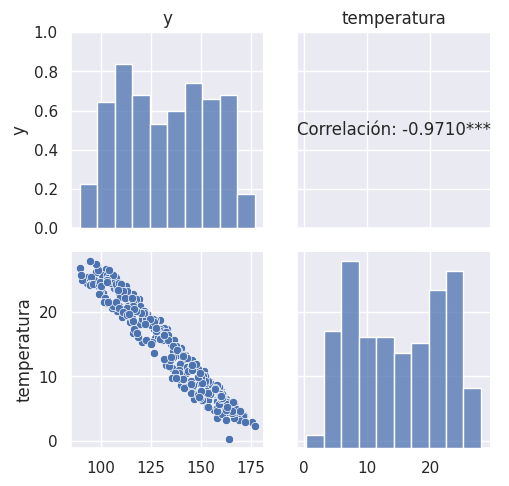

In [34]:
def correlacion(x, y, **kws):
    r, p = pearsonr(x, y)

    ax = plt.gca()
    ax.annotate(
        f"Correlación: {r:.4f}{'***' if p < 0.05 else ' '}",
        xy = (0.5, 0.5),
        xycoords = 'axes fraction',
        ha = 'center',
        va = 'center'
    )

df_plot = df_train[['y', 'temperatura']].copy()

pg = sns.PairGrid(df_plot)
pg.map_diag(sns.histplot)
pg.map_upper(correlacion)
pg.map_lower(sns.scatterplot)
pg.add_legend()

pg.set(xlabel='')
for i, col in enumerate(df_plot.columns):
    pg.axes[0,i].set_title(col)

una regresión lineal se ajusta perfecto en este caso

In [37]:
mlf = MLForecast(models = [LinearRegression()], freq='d')

mlf.fit(
    df = df_train,
    fitted = True, # para hacer la predicción in-sample y obtener los residuos
    static_features = [] # para indicar que se usa una exógena de valores contínuos
    )

pred_is = mlf.forecast_fitted_values() 
pred_is

,unique_id,ds,y,LinearRegression
0,demanda_electricidad,2025-01-01,131.2,130.233969
1,demanda_electricidad,2025-01-02,135.1,132.334368
2,demanda_electricidad,2025-01-03,129.1,128.433627
3,demanda_electricidad,2025-01-04,117.4,123.932773
4,demanda_electricidad,2025-01-05,120.7,131.434197
...,...,...,...,...
353,demanda_electricidad,2025-12-20,131.7,139.235677
354,demanda_electricidad,2025-12-21,134.8,138.035449
355,demanda_electricidad,2025-12-22,145.3,141.936189
356,demanda_electricidad,2025-12-23,140.8,137.135278


<Axes: xlabel='ds', ylabel='y'>

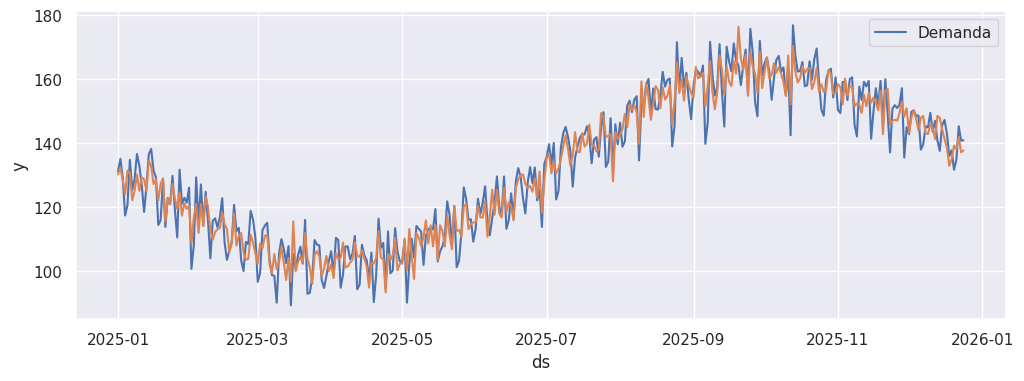

In [38]:
sns.lineplot(pred_is, x = 'ds', y = 'y', label = 'Demanda')
sns.lineplot(pred_is, x = 'ds', y = 'LinearRegression')

Este es el gráfico que captura las variaciónes abruptas de la serie de tiempo implementando una regresión lineal en la variable exógena.

A partir de este punto vamos a necesitar obtener los residuos y de ahi entrenar un modelo SARIMAX